In [18]:
import kagglehub
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
# Download dataset
path = kagglehub.dataset_download("akashrayhan/yoga-82")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\marti\.cache\kagglehub\datasets\akashrayhan\yoga-82\versions\1


In [20]:
# Number of classes

def count_classes_and_samples(path: Path):
    samples = 0
    for entry in path.iterdir():
        if not entry.is_dir():
            continue
        class_samples = count_folders(entry)
        samples += class_samples
    classes = count_folders(path)
    return samples, classes

def count_folders(path):
    return sum(1 for _ in path.iterdir())

path = Path(path)

for set in ['train', 'test', 'valid']:    
    samples, classes = count_classes_and_samples(path / set)
    print(f'{set} size: {samples}, classes: {classes}')

train size: 11652, classes: 82
test size: 1764, classes: 82
valid size: 3351, classes: 82


In [21]:
# Image resolution stats

VALID_EXT = {".jpg", ".jpeg"}

def iter_images(split_path: Path):
    for class_dir in split_path.iterdir():
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                yield img_path


def get_image_size(img_path: Path):
    with Image.open(img_path) as img:
        return img.size  # (w, h)


def compute_split_stats(split_path: Path):
    widths, heights = [], []
    for img_path in iter_images(split_path):
        try:
            w, h = get_image_size(img_path)
            widths.append(w)
            heights.append(h)
        except Exception:
            continue
    if not widths:
        return None
    widths = np.array(widths)
    heights = np.array(heights)
    return {
        "count": len(widths),
        "min_width": int(widths.min()),
        "max_width": int(widths.max()),
        "avg_width": float(widths.mean()),
        "min_height": int(heights.min()),
        "max_height": int(heights.max()),
        "avg_height": float(heights.mean()),
    }

# ---- main ----

split_stats = {}

for split in ["train", "valid", "test"]:
    stats = compute_split_stats(path / split)
    split_stats[split] = stats

    print(f"\n=== {split.upper()} ===")
    if stats is None:
        print("No images found.")
        continue
    print(f"Images: {stats['count']}")
    print(f"Width : min={stats['min_width']}, max={stats['max_width']}, avg={stats['avg_width']:.1f}")
    print(f"Height: min={stats['min_height']}, max={stats['max_height']}, avg={stats['avg_height']:.1f}")

c:\Users\marti\Documents\University\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



=== TRAIN ===
Images: 11652
Width : min=1, max=6240, avg=744.3
Height: min=1, max=5244, avg=622.4

=== VALID ===
Images: 3351
Width : min=53, max=6016, avg=760.8
Height: min=49, max=5184, avg=633.4

=== TEST ===
Images: 1764
Width : min=1, max=6016, avg=776.8
Height: min=1, max=4000, avg=618.1


In [22]:
IMG_SIZE  = 384
RESIZE_TO = 440  # resize shorter side (~1.15x crop size), then crop

print("Average image resolutions in dataset:")
for split, stats in split_stats.items():
    if stats:
        print(f"  {split:5s}: {stats['avg_width']:.0f} x {stats['avg_height']:.0f} px")
print(f"\nTraining at: {IMG_SIZE}x{IMG_SIZE}  (shorter side resized to {RESIZE_TO} before crop)\n")

train_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(path / "train", transform=train_transform)
val_ds   = datasets.ImageFolder(path / "valid", transform=val_test_transform)
test_ds  = datasets.ImageFolder(path / "test",  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_ds.classes)
print("Classes:", num_classes)

Average image resolutions in dataset:
  train: 744 x 622 px
  valid: 761 x 633 px
  test : 777 x 618 px

Training at: 384x384  (shorter side resized to 440 before crop)

Classes: 82


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device to be used: ", device)

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

Device to be used:  cuda


In [24]:
from collections import Counter

# Class-weighted loss to handle imbalance
class_counts = Counter(label for _, label in train_ds.samples)
class_weights = torch.tensor(
    [len(train_ds) / (num_classes * class_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [25]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return correct / total, all_preds, all_labels

In [26]:
EPOCHS  = 15 if device == "cuda" else 5
PATIENCE = 3

best_val_acc      = 0.0
patience_counter  = 0

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d}: loss={loss:.4f}  val_acc={acc:.4f}  lr={lr:.2e}")

    if acc > best_val_acc:
        best_val_acc = acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (patience={PATIENCE}). Best val_acc: {best_val_acc:.4f}")
            break

model.load_state_dict(torch.load("best_model.pt"))
print(f"\nRestored best model  val_acc={best_val_acc:.4f}")

Epoch  1: loss=3.8105  val_acc=0.4587  lr=9.89e-05
Epoch  2: loss=2.2018  val_acc=0.6604  lr=9.57e-05
Epoch  3: loss=1.4898  val_acc=0.7359  lr=9.05e-05
Epoch  4: loss=1.1391  val_acc=0.7654  lr=8.35e-05
Epoch  5: loss=0.9323  val_acc=0.7911  lr=7.50e-05
Epoch  6: loss=0.7964  val_acc=0.8063  lr=6.55e-05
Epoch  7: loss=0.6855  val_acc=0.8236  lr=5.52e-05
Epoch  8: loss=0.6157  val_acc=0.8269  lr=4.48e-05
Epoch  9: loss=0.5580  val_acc=0.8350  lr=3.45e-05
Epoch 10: loss=0.5175  val_acc=0.8371  lr=2.50e-05
Epoch 11: loss=0.4859  val_acc=0.8392  lr=1.65e-05
Epoch 12: loss=0.4703  val_acc=0.8457  lr=9.55e-06
Epoch 13: loss=0.4500  val_acc=0.8445  lr=4.32e-06
Epoch 14: loss=0.4389  val_acc=0.8400  lr=1.09e-06
Epoch 15: loss=0.4296  val_acc=0.8415  lr=0.00e+00

Early stopping at epoch 15 (patience=3). Best val_acc: 0.8457

Restored best model  val_acc=0.8457


In [27]:
acc, preds, labels = evaluate(model, test_loader)

print("Test accuracy:", acc)

print("\nClassification report:")
print(classification_report(labels, preds, target_names=test_ds.classes))

cm = confusion_matrix(labels, preds)
print("\nConfusion matrix shape:", cm.shape)

Test accuracy: 0.8509070294784581

Classification report:
                                                                           precision    recall  f1-score   support

                                                       Akarna_Dhanurasana       0.82      1.00      0.90         9
                              Bharadvajas_Twist_pose_or_Bharadvajasana_I_       0.56      0.56      0.56         9
                                         Boat_Pose_or_Paripurna_Navasana_       0.88      0.90      0.89        31
                                     Bound_Angle_Pose_or_Baddha_Konasana_       0.77      0.92      0.84        26
                                                 Bow_Pose_or_Dhanurasana_       0.96      1.00      0.98        23
                                 Bridge_Pose_or_Setu_Bandha_Sarvangasana_       1.00      0.86      0.92        28
                                                 Camel_Pose_or_Ustrasana_       0.94      0.97      0.96        34
                     

In [28]:
report = classification_report(labels, preds, target_names=test_ds.classes, output_dict=True)

weak_classes = sorted(
    [(k, v["f1-score"]) for k, v in report.items() if k in test_ds.classes],
    key=lambda x: x[1]
)

print("Worst classes:")
print(weak_classes[:10])

Worst classes:
[('Scorpion_pose_or_vrischikasana', 0.35294117647058826), ('Wide-Angle_Seated_Forward_Bend_pose_or_Upavistha_Konasana_', 0.4888888888888889), ('Tortoise_Pose', 0.5), ('Cockerel_Pose', 0.5384615384615384), ('Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 0.5454545454545454), ('Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 0.5555555555555556), ('Head-to-Knee_Forward_Bend_pose_or_Janu_Sirsasana_', 0.5714285714285714), ('Handstand_pose_or_Adho_Mukha_Vrksasana_', 0.6274509803921569), ('Corpse_Pose_or_Savasana_', 0.6865671641791045), ('Split pose', 0.6984126984126984)]


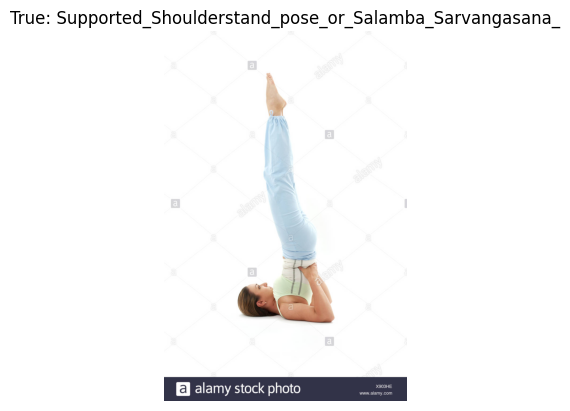

Predicted : Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_ (98.2%)
True label: Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_
Correct   : True


In [29]:
import random
import matplotlib.pyplot as plt

random.seed(42)

img_path, true_idx = random.choice(val_ds.samples)
true_label = val_ds.classes[true_idx]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.title(f"True: {true_label}")
plt.axis("off")
plt.show()

img_tensor = val_test_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    out = model(img_tensor)
    pred_idx = out.argmax(dim=1).item()
    confidence = torch.softmax(out, dim=1)[0, pred_idx].item()

pred_label = val_ds.classes[pred_idx]
print(f"Predicted : {pred_label} ({confidence:.1%})")
print(f"True label: {true_label}")
print(f"Correct   : {pred_label == true_label}")

In [32]:
import torch.nn.functional as F
from tqdm import tqdm

EMBEDDINGS_PATH = "train_embeddings.npz"

def extract_features(imgs):
    feats = model.features(imgs)
    feats = model.avgpool(feats)
    return torch.flatten(feats, 1)

if Path(EMBEDDINGS_PATH).exists():
    data = np.load(EMBEDDINGS_PATH)
    train_embeddings = torch.from_numpy(data["embeddings"])
    print(f"Loaded index from {EMBEDDINGS_PATH}  shape: {train_embeddings.shape}")
else:
    index_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)

    train_embeddings = []
    model.eval()
    with torch.no_grad():
        for x, _ in tqdm(index_loader, desc="Indexing train set"):
            train_embeddings.append(extract_features(x.to(device)).cpu())

    train_embeddings = torch.cat(train_embeddings, dim=0)
    train_embeddings = F.normalize(train_embeddings, dim=1)

    np.savez(EMBEDDINGS_PATH, embeddings=train_embeddings.numpy())
    print(f"Saved index to {EMBEDDINGS_PATH}  shape: {train_embeddings.shape}")

Indexing train set: 100%|██████████| 183/183 [00:57<00:00,  3.20it/s]

Saved index to train_embeddings.npz  shape: torch.Size([11652, 1280])


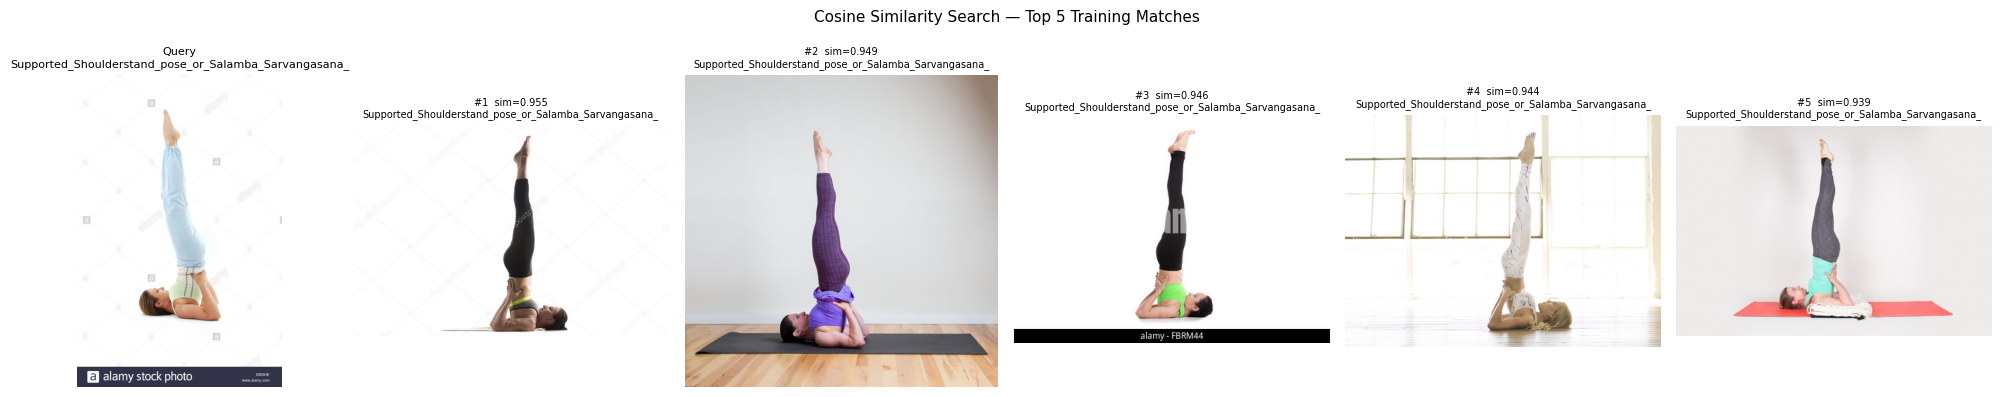

In [35]:
with torch.no_grad():
    query_emb = F.normalize(extract_features(img_tensor.to(device)).cpu(), dim=1)

sims = (train_embeddings @ query_emb.T).squeeze()
top5 = sims.topk(5)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(img)
axes[0].set_title(f"Query\n{true_label}", fontsize=8)
axes[0].axis("off")

for i, (idx, score) in enumerate(zip(top5.indices, top5.values)):
    match_path, match_class_idx = train_ds.samples[idx.item()]
    match_label = train_ds.classes[match_class_idx]
    match_img = Image.open(match_path).convert("RGB")
    axes[i + 1].imshow(match_img)
    axes[i + 1].set_title(f"#{i+1}  sim={score:.3f}\n{match_label}", fontsize=7)
    axes[i + 1].axis("off")

plt.suptitle("Cosine Similarity Search — Top 5 Training Matches", fontsize=11)
plt.tight_layout()
plt.show()